# Box Transpose Calibration

Reproduces the calibration of **τ** and **μ** as described in Section 3.1.2, following Algorithm 3a.

**Phase 1 — find τ**
Fix D_mid and sweep D_post over the valid shape population (Eq. 6). τ is the smallest D_post where throughput first meets or exceeds 50% of observed peak.

**Phase 2 — find μ**
Run steps drawn from the Eq. 6 shape population across all ranks. μ is the mean throughput over steps with D_post ≥ τ (the throughput knee from Phase 1).

In [1]:
import subprocess

try:
    gpu_name = subprocess.run(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
        capture_output=True,
        text=True,
        check=True
    ).stdout.strip()
    print(f'GPU we are using: {gpu_name}')
except FileNotFoundError:
    print('nvidia-smi not found')
except subprocess.CalledProcessError as exc:
    print(f'Failed to query GPU: {exc}')

GPU we are using: NVIDIA RTX PRO 6000 Blackwell Workstation Edition


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import os
DATA = Path(os.environ.get('BT_MICRO_RESULTS',
                            'calibration/find_edge_costs/micro_benchmark_results.jsonl'))
rows = [json.loads(l) for l in DATA.open() if l.strip()]

d_post_rows = sorted(
    [r for r in rows if r['experiment'] == 'd_post_sweep'
     and not r.get('error') and r.get('throughput_bytes_ms', 0) > 0],
    key=lambda r: r['d_post']
)
step_rows = [
    r for r in rows if r['experiment'] == 'step_throughput'
    and not r.get('error') and r.get('throughput_bytes_ms', 0) > 0
]

N = 1_000_000_000
print(f'D_post sweep rows   : {len(d_post_rows)}')
print(f'Step throughput rows: {len(step_rows)}')

D_post sweep rows   : 36
Step throughput rows: 2012


### Phase 1 - Derive τ

D_mid is held fixed at 10,000. D_post is swept across all valid divisors of N for the target (N, r) population.
τ = the first D_post where measured throughput ≥ 50% of the peak.

In [3]:
d_post_vals = [r['d_post'] for r in d_post_rows]
throughputs  = [r['throughput_bytes_ms'] / 1e6 for r in d_post_rows]  # GB/s

peak = max(throughputs)
half = peak * 0.5

tau = next(dp for dp, tp in zip(d_post_vals, throughputs) if tp >= half)

print(f'Peak throughput : {peak:.1f} GB/s')
print(f'50% threshold   : {half:.1f} GB/s')
print(f'τ               = {tau}   (smallest D_post where throughput meets or exceeds 50% of peak)')

Peak throughput : 1451.9 GB/s
50% threshold   : 726.0 GB/s
τ               = 80   (smallest D_post where throughput meets or exceeds 50% of peak)


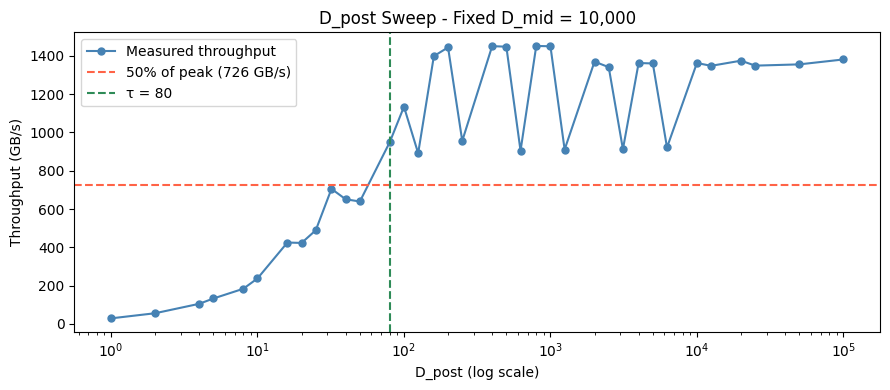

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(d_post_vals, throughputs, 'o-', color='steelblue', markersize=5, label='Measured throughput')
ax.axhline(half, color='tomato',   linestyle='--', label=f'50% of peak ({half:.0f} GB/s)')
ax.axvline(tau,  color='seagreen', linestyle='--', label=f'τ = {tau}')

ax.set_xscale('log')
ax.set_xlabel('D_post (log scale)')
ax.set_ylabel('Throughput (GB/s)')
ax.set_title('D_post Sweep - Fixed D_mid = 10,000')
ax.legend()
plt.tight_layout()
plt.show()

### Phase 2 - Derive μ

Steps are drawn from the Eq. 6 shape population across ranks 3-6.
μ is the mean throughput over steps with D_post ≥ τ (same threshold used for Dijkstra graph pruning).

In [5]:
TAU = 80  # throughput knee from Phase 1 (graph pruning threshold)

high_vals = [r['throughput_bytes_ms'] for r in step_rows if r['d_post'] >= TAU]

mu = float(np.mean(high_vals)) / 1e6  # GB/s

print(f'τ (throughput knee)         = {TAU} elements')
print(f'Steps with D_post >= τ      : {len(high_vals):,}  ->  μ = {mu:.1f} GB/s')

D_post* (routing threshold) = 100 elements
Steps with D_post >= D_post*: 1,085  ->  μ = 69.7 GB/s


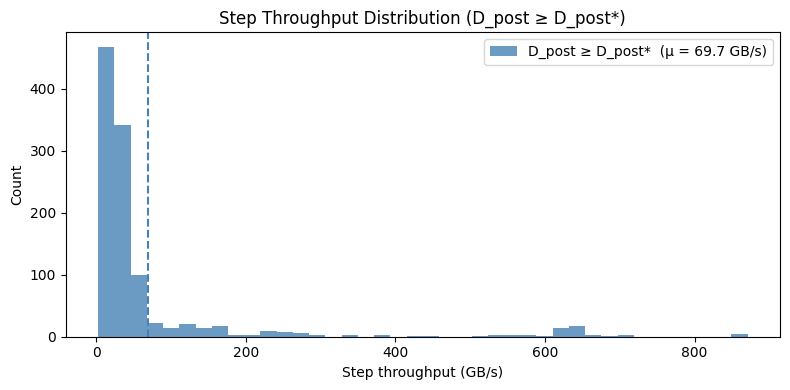

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist([r['throughput_bytes_ms'] / 1e6 for r in step_rows if r['d_post'] >= TAU],
        bins=40, alpha=0.8, color='steelblue', label=f'D_post ≥ τ  (μ = {mu:.1f} GB/s)')

ax.axvline(mu, color='steelblue', linestyle='--')

ax.set_xlabel('Step throughput (GB/s)')
ax.set_ylabel('Count')
ax.set_title('Step Throughput Distribution (D_post ≥ τ)')
ax.legend()
plt.tight_layout()
plt.show()

## Summary

These are the constants that go into `_plan.py`. Note: D_post* comes from the routing benchmark study (Section 3.2), not from this calibration procedure.

In [7]:
print('=' * 44)
print('  CALIBRATED CONSTANTS')
print('=' * 44)
print(f'  τ      = {tau}   (hardware throughput knee, elements)')
print(f'  μ      = {mu:.1f} GB/s  (mean throughput for D_post >= τ)')
print()
print('Stored in _plan.py as:')
print(f'  TAU = {tau}')
print(f'  MU  = {mu:.1f}')
print()
print(f'D_post* = 100 elements  (from Section 3.2 routing study, stored as D_POST_STAR)')

  CALIBRATED CONSTANTS
  τ      = 80   (hardware throughput knee, elements)
  μ      = 69.7 GB/s  (mean throughput for D_post >= D_post*)

Stored in _plan.py as:
  TAU = 80
  MU  = 69.7

D_post* = 100 elements  (from Section 3.2 routing study, stored as D_POST_STAR)
